In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

from plotting.cell_state_plotters import plot_cell_state_2d, plot_cell_state_3d

In [3]:
# full_q

full_q_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

# q_filter 

q_filter_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_410.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_553.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))


In [5]:
mode = "normal"

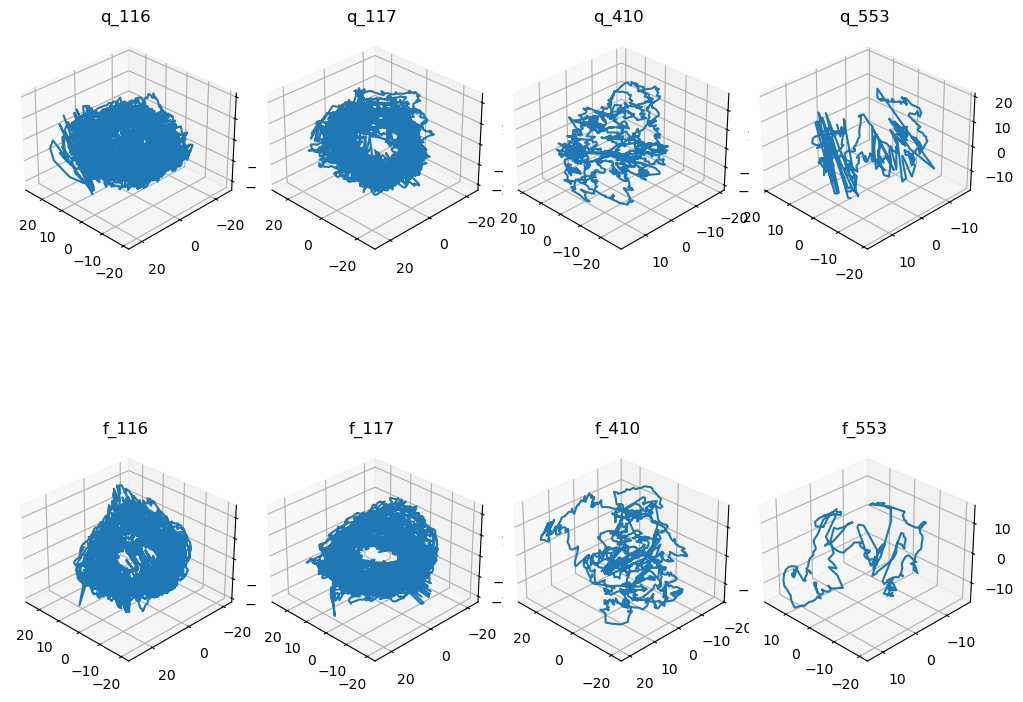

In [ ]:
fig, axs = plt.subplots(2,4, figsize=(10,10), subplot_kw={"projection": "3d"})

for ax, array, title in zip(
	axs.ravel(),
	list(map(lambda x: x[mode], full_q_states)) + list(map(lambda x: x[mode], q_filter_states)),
	["q_116", "q_117","q_410", "q_553", "f_116", "f_117", "f_410", "f_553"]):
	
	# Assign every 365 points the same color, to look for seasonal patterns.
	point_colors = np.arange(len(array)) // 365

	plot_cell_state_3d(
		cell_state_array=array,
		ax=ax,
		connect=True,
		ax_view_params={"elev": 30, "azim": 135},
		title=title,
	)

plt.tight_layout()

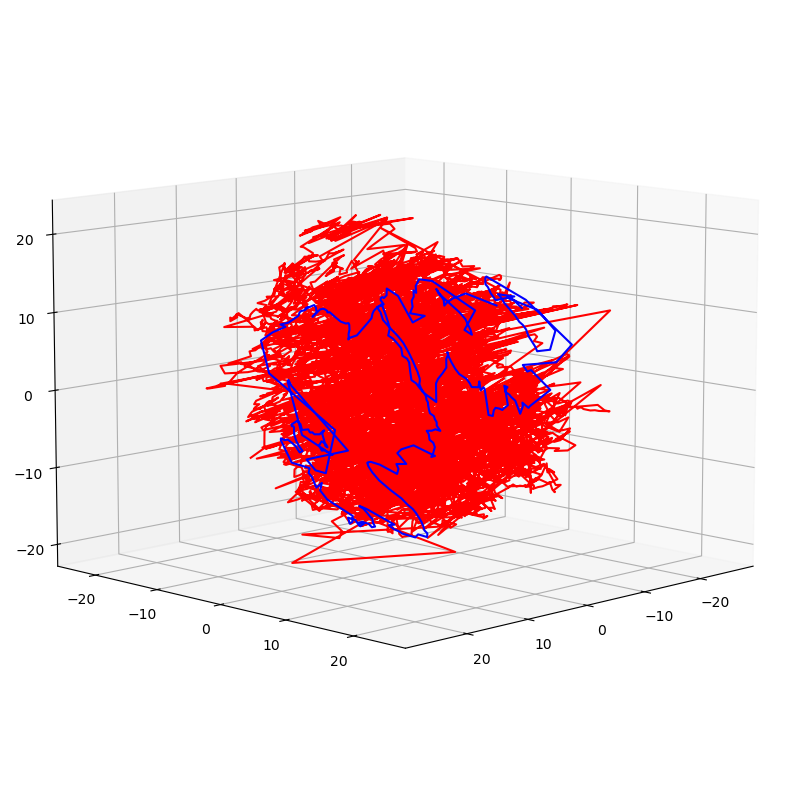

In [7]:
fig, ax = plt.subplots(1,1, figsize=(10,10), subplot_kw={"projection": "3d"})

plot_cell_state_3d(
    cell_state_array=full_q_states[1][mode],
    ax=ax,
    connect=True,
    color="red",
)

plot_cell_state_3d(
    cell_state_array=q_filter_states[1][mode],
    ax=ax,
	connect=True,
    color="blue",
)

ax.view_init(10, 45)

In [8]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_means_mds.p", "rb") as f: 
    filter_means_mds = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_means_mds.p", "rb") as f: 
    full_means_mds = pickle.load(f)

In [4]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [35]:
[full_means_mds["2"][m] for m in ["normal", "raw"]]

[array([[ -7.27668299, -12.77270837],
        [ -4.80627865, -17.26159559],
        [ 15.3499005 ,  -3.80030428],
        ...,
        [ -0.91543745,  20.13879898],
        [-10.02774685,  21.71231238],
        [ -6.7074223 ,  19.9314013 ]]),
 array([[-198.09920949, -347.63544018],
        [-110.03282663, -392.94764629],
        [-249.03014823, -191.17924395],
        ...,
        [ -37.58600499,  415.45645669],
        [-225.98147398,  347.75360269],
        [-109.89926216,  376.8509868 ]])]

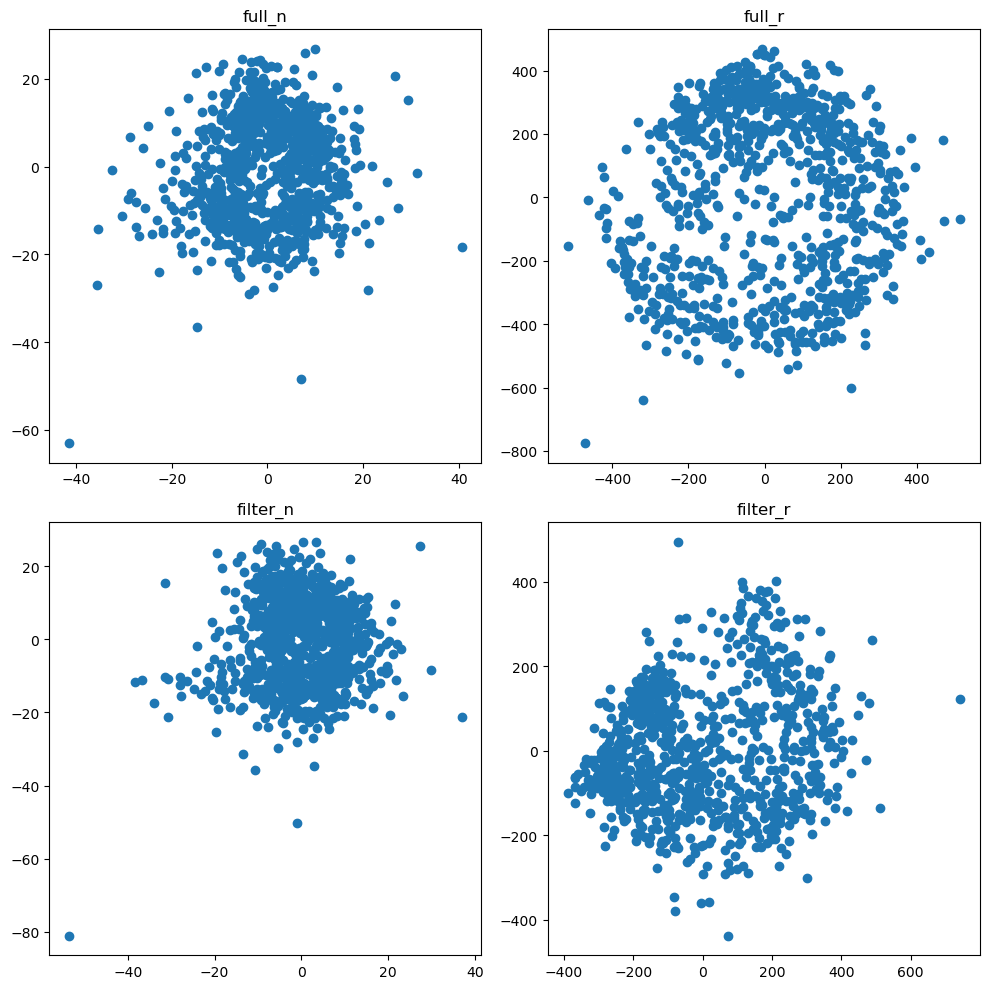

In [49]:
fig, axs = plt.subplots(2,2, figsize=(10,10))

for ax, array, title in zip(
    axs.ravel(),
	[full_means_mds["2"][m] for m in ["normal", "raw"]] + [filter_means_mds["2"][m] for m in ["normal", "raw"]],
	["full_n","full_r", "filter_n", "filter_r"]):

    plot_cell_state_2d(array, ax=ax, title=title)

plt.tight_layout()

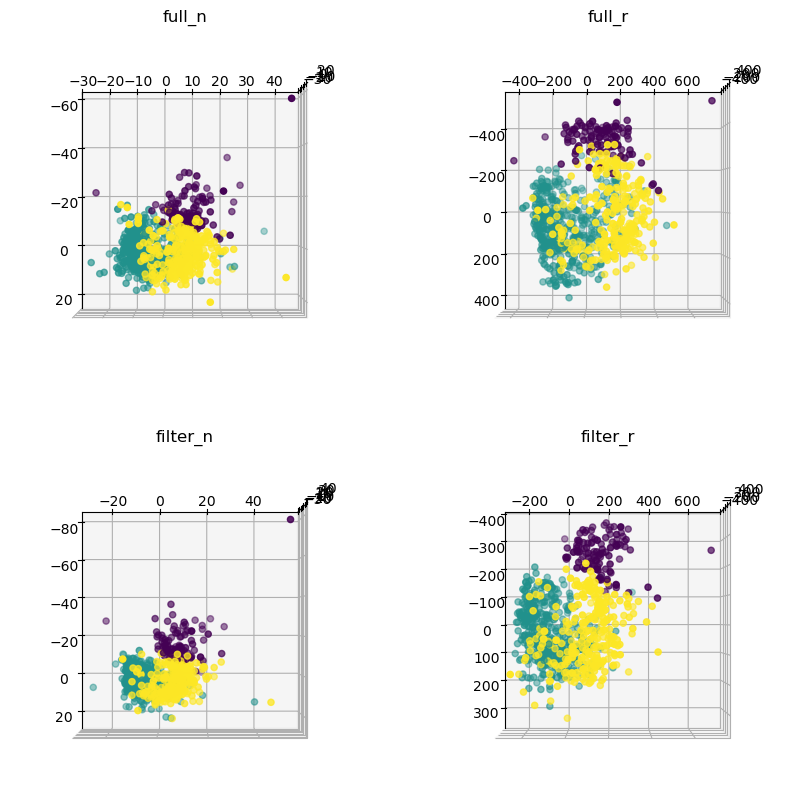

In [65]:
fig, axs = plt.subplots(2,2, figsize=(10,10), subplot_kw={"projection": "3d"})

for ax, array, title in zip(
    axs.ravel(),
	[full_means_mds["3"][m] for m in ["normal", "raw"]] + [filter_means_mds["3"][m] for m in ["normal", "raw"]],
	["full_n","full_r", "filter_n", "filter_r"]):

    
    plot_cell_state_3d(array, ax=ax, ax_view_params={"elev":90, "azim": 0}, title=title, c=strata_ids)

<Axes3D: >

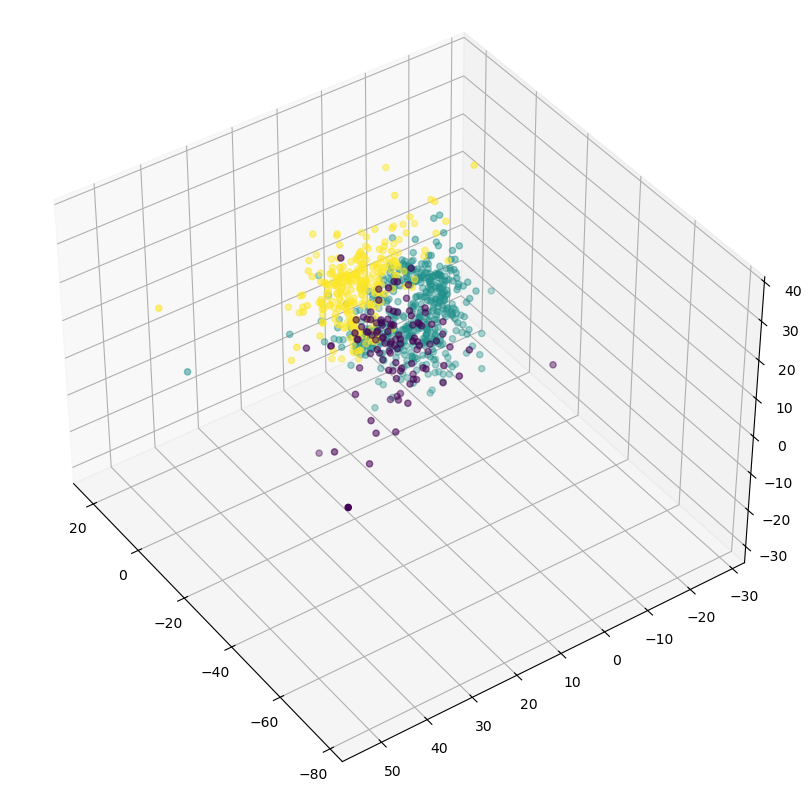

In [29]:

plot_cell_state_3d(filter_means_mds["3"]["normal"], ax_view_params={"elev":40, "azim": 145}, fig_args={"figsize":(10,10)}, c=strata_ids)